# Entrega 3 — Chunking de Manifestações Longas

**Desafio de Ouvidoria Municipal**

Este notebook trabalha as 5 manifestações mais longas (> 500 caracteres) do corpus de 40
manifestações, aplicando a estratégia `RecursiveCharacterTextSplitter` do LangChain com duas
configurações diferentes de `(chunk_size, chunk_overlap)`, e responde às três perguntas do
enunciado:

1. Como o overlap influencia a coesão semântica entre chunks consecutivos?
2. Qual configuração preserva melhor o sentido das denúncias?
3. Os chunks de uma mesma manifestação ficam próximos no espaço 2D (PCA/t-SNE)?

**Nota sobre embeddings:** o enunciado sugere modelos como `paraphrase-multilingual-MiniLM-L12-v2`
via `sentence-transformers`. Neste ambiente de desenvolvimento não há acesso à internet para
baixar pesos de modelos pré-treinados do Hugging Face (testado e confirmado: `huggingface.co`
retorna erro de conexão bloqueada). Por isso, a representação vetorial usada abaixo é TF-IDF
(via `scikit-learn`) reduzida com PCA/t-SNE — uma simulação documentada e reprodutível. Em um
ambiente com internet, basta trocar a função `gerar_embeddings` por
`SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2').encode(textos)` sem alterar o
restante da análise.

In [1]:
import sys
sys.path.append(".")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from langchain_text_splitters import RecursiveCharacterTextSplitter

from corpus_manifestacoes import MANIFESTACOES, IDS_LONGAS_ESPERADAS

df = pd.DataFrame(MANIFESTACOES)
df["tamanho"] = df["texto"].str.len()
df.sort_values("tamanho", ascending=False).head(8)[["id", "categoria", "tamanho"]]

,id,categoria,tamanho
39,M045,meio ambiente,1188
38,M044,educacao,1094
37,M043,seguranca,1045
36,M042,saude,1003
35,M041,infraestrutura,986
7,M001,seguranca,153
31,M032,saude,152
6,M029,meio ambiente,152


## 1. Selecionando as 5 manifestações mais longas

Confirmando que são as mesmas 5 manifestações desenhadas no corpus para ultrapassar 500 caracteres.

In [2]:
longas = df.sort_values("tamanho", ascending=False).head(5).reset_index(drop=True)
print(f"IDs esperados: {IDS_LONGAS_ESPERADAS}")
print(f"IDs encontrados: {list(longas['id'])}")
assert set(longas["id"]) == set(IDS_LONGAS_ESPERADAS), "As 5 manifestações longas não batem com o esperado"
longas[["id", "categoria", "tamanho"]]

IDs esperados: ['M041', 'M042', 'M043', 'M044', 'M045']
IDs encontrados: ['M045', 'M044', 'M043', 'M042', 'M041']


,id,categoria,tamanho
0,M045,meio ambiente,1188
1,M044,educacao,1094
2,M043,seguranca,1045
3,M042,saude,1003
4,M041,infraestrutura,986


## 2. Duas configurações de chunking

Testamos duas configurações claramente diferentes:

- **Config A — chunks pequenos e pouco overlap**: `chunk_size=200`, `chunk_overlap=20` (10% de overlap)
- **Config B — chunks maiores e overlap generoso**: `chunk_size=350`, `chunk_overlap=100` (~29% de overlap)

O `RecursiveCharacterTextSplitter` tenta quebrar primeiro em parágrafos, depois frases, depois
palavras, o que ajuda a preservar unidades de sentido mesmo com `chunk_size` pequeno.

In [3]:
CONFIGS = {
    "A (pequeno, pouco overlap)": {"chunk_size": 200, "chunk_overlap": 20},
    "B (maior, overlap generoso)": {"chunk_size": 350, "chunk_overlap": 100},
}

resultados_chunking = {}

for nome_config, params in CONFIGS.items():
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=params["chunk_size"],
        chunk_overlap=params["chunk_overlap"],
        separators=["\n\n", "\n", ". ", " ", ""],
    )
    registros = []
    for _, row in longas.iterrows():
        chunks = splitter.split_text(row["texto"])
        for i, chunk in enumerate(chunks):
            registros.append({
                "manifestacao_id": row["id"],
                "categoria": row["categoria"],
                "chunk_idx": i,
                "chunk_texto": chunk,
                "chunk_tamanho": len(chunk),
            })
    resultados_chunking[nome_config] = pd.DataFrame(registros)
    print(f"{nome_config}: {len(registros)} chunks gerados no total, "
          f"media de {pd.DataFrame(registros)['chunk_tamanho'].mean():.0f} caracteres por chunk")


A (pequeno, pouco overlap): 40 chunks gerados no total, media de 137 caracteres por chunk
B (maior, overlap generoso): 24 chunks gerados no total, media de 227 caracteres por chunk


In [4]:
# Exemplo: chunks gerados para a manifestacao M045 (a mais longa) nas duas configuracoes
for nome_config, df_chunks in resultados_chunking.items():
    print(f"\n=== {nome_config} — M045 ===")
    exemplo = df_chunks[df_chunks["manifestacao_id"] == "M045"]
    for _, r in exemplo.iterrows():
        print(f"  chunk {r['chunk_idx']} ({r['chunk_tamanho']} chars): {r['chunk_texto'][:90]}...")



=== A (pequeno, pouco overlap) — M045 ===
  chunk 0 (198 chars): Escrevo em nome de um grupo de moradores do bairro proximo ao Parque das Garcas para relat...
  chunk 1 (54 chars): que fica a poucos metros das primeiras casas do bairro...
  chunk 2 (197 chars): . Ha cerca de dois meses, comecamos a notar caminhoes descarregando material que parece en...
  chunk 3 (49 chars): e pela coloracao estranha que fica no solo depois...
  chunk 4 (196 chars): . Isso ja causou a morte visivel de vegetacao nativa em uma faixa considera da area e teme...
  chunk 5 (37 chars): artesianos para abastecimento de agua...
  chunk 6 (145 chars): . Fizemos denuncia ao orgao ambiental municipal ha cerca de um mes, mas ate agora nao rece...
  chunk 7 (200 chars): . Temos fotos e alguns videos dos caminhoes realizando o descarte em horarios sempre proxi...
  chunk 8 (69 chars): irregularidade e escolhem esse horario para dificultar a fiscalizacao...
  chunk 9 (100 chars): . Pedimos providencias urgentes ante

## 3. Embeddings dos chunks (TF-IDF, ver nota sobre substituição de sentence-transformers)

Para medir coesão semântica entre chunks consecutivos, geramos uma representação vetorial de
cada chunk. O vocabulário TF-IDF é ajustado sobre **todos os chunks de todas as configurações
juntos**, para que os vetores fiquem no mesmo espaço e sejam comparáveis entre si.

In [5]:
def gerar_embeddings(vectorizer, textos):
    """Gera vetores TF-IDF para uma lista de textos, usando um vectorizer já ajustado."""
    return vectorizer.transform(textos).toarray()

# Ajusta o vocabulario TF-IDF com todos os chunks das duas configuracoes + os textos originais
todos_os_textos = []
for df_chunks in resultados_chunking.values():
    todos_os_textos.extend(df_chunks["chunk_texto"].tolist())

vectorizer = TfidfVectorizer(lowercase=True, strip_accents="unicode", min_df=1)
vectorizer.fit(todos_os_textos)

for nome_config, df_chunks in resultados_chunking.items():
    embeddings = gerar_embeddings(vectorizer, df_chunks["chunk_texto"].tolist())
    resultados_chunking[nome_config] = df_chunks.assign(embedding=list(embeddings))

print("Embeddings gerados. Dimensao do vocabulario TF-IDF:", len(vectorizer.get_feature_names_out()))

Embeddings gerados. Dimensao do vocabulario TF-IDF: 443


## 4. Coesão semântica entre chunks consecutivos

Para cada manifestação, calculamos a similaridade de cosseno entre cada par de chunks
**consecutivos** (chunk 0↔1, 1↔2, etc.) e tiramos a média por manifestação e por configuração.
Uma coesão média mais alta indica que os chunks preservam melhor a continuidade do assunto.

In [6]:
def coesao_media_por_config(df_chunks):
    coesoes = []
    for manif_id, grupo in df_chunks.groupby("manifestacao_id"):
        grupo = grupo.sort_values("chunk_idx")
        vetores = np.stack(grupo["embedding"].values)
        if len(vetores) < 2:
            continue
        sims = [
            cosine_similarity(vetores[i:i+1], vetores[i+1:i+2])[0, 0]
            for i in range(len(vetores) - 1)
        ]
        coesoes.append({
            "manifestacao_id": manif_id,
            "n_chunks": len(vetores),
            "coesao_media": float(np.mean(sims)),
        })
    return pd.DataFrame(coesoes)

tabela_coesao = {}
for nome_config, df_chunks in resultados_chunking.items():
    tabela_coesao[nome_config] = coesao_media_por_config(df_chunks)
    media_geral = tabela_coesao[nome_config]["coesao_media"].mean()
    print(f"{nome_config}: coesao media geral = {media_geral:.4f}")

pd.concat(
    {nome: t.set_index("manifestacao_id")["coesao_media"] for nome, t in tabela_coesao.items()},
    axis=1
)

A (pequeno, pouco overlap): coesao media geral = 0.0866
B (maior, overlap generoso): coesao media geral = 0.1096


,"A (pequeno, pouco overlap)","B (maior, overlap generoso)"
manifestacao_id,,
M041,0.074079,0.088514
M042,0.111308,0.253477
M043,0.067323,0.086580
M044,0.103706,0.083411
M045,0.076578,0.036202


### Discussão: como o overlap influencia a coesão?

A Config B (chunks maiores, `chunk_overlap=100`, quase 29% do chunk) tende a mostrar coesão
média mais alta entre chunks consecutivos do que a Config A (`chunk_overlap=20`, apenas 10%).
Isso é esperado: quanto maior o overlap, mais texto é compartilhado literalmente entre dois
chunks vizinhos, então mais termos do vocabulário TF-IDF aparecem em ambos, inflando a
similaridade de cosseno. Overlap pequeno cria fronteiras mais abruptas entre chunks, o que pode
cortar uma frase ao meio e separar termos que pertencem à mesma ideia em chunks diferentes,
reduzindo a coesão medida. Por outro lado, overlap **excessivo** infla artificialmente a
coesão sem necessariamente melhorar a qualidade da segmentação, porque parte da "semelhança"
é apenas texto duplicado, não conteúdo semântico novo relacionado.

### Qual configuração preserva melhor o sentido das denúncias?

Olhando os exemplos impressos da manifestação M045 (a mais longa, sobre descarte irregular de
resíduos), a **Config B** tende a manter frases completas dentro de cada chunk com menos cortes
no meio de uma ideia (por exemplo, a frase sobre contaminação do lençol freático fica inteira
em um único chunk), enquanto a Config A, por ser mais restritiva no tamanho, às vezes corta uma
oração ao meio entre um chunk e o seguinte. Para textos de denúncia, onde o contexto entre causa
e consequência é importante para o ouvidor entender a gravidade do relato, a Config B preserva
melhor o sentido geral, ao custo de gerar menos chunks (portanto, menos granularidade para busca
semântica muito específica). A escolha ideal depende do uso: para resumir a denúncia inteira,
Config B é melhor; para busca semântica muito granular por um trecho específico, chunks menores
como na Config A podem ajudar, desde que o overlap não seja tão baixo a ponto de cortar ideias
no meio.

## 5. Visualização dos chunks em 2D (PCA e t-SNE)

Projetamos os embeddings de todos os chunks de cada configuração em 2D, coloridos por
manifestação de origem, para checar visualmente se os chunks de uma mesma manifestação ficam
próximos entre si (o que indicaria que o chunking preserva a identidade temática do documento
original).

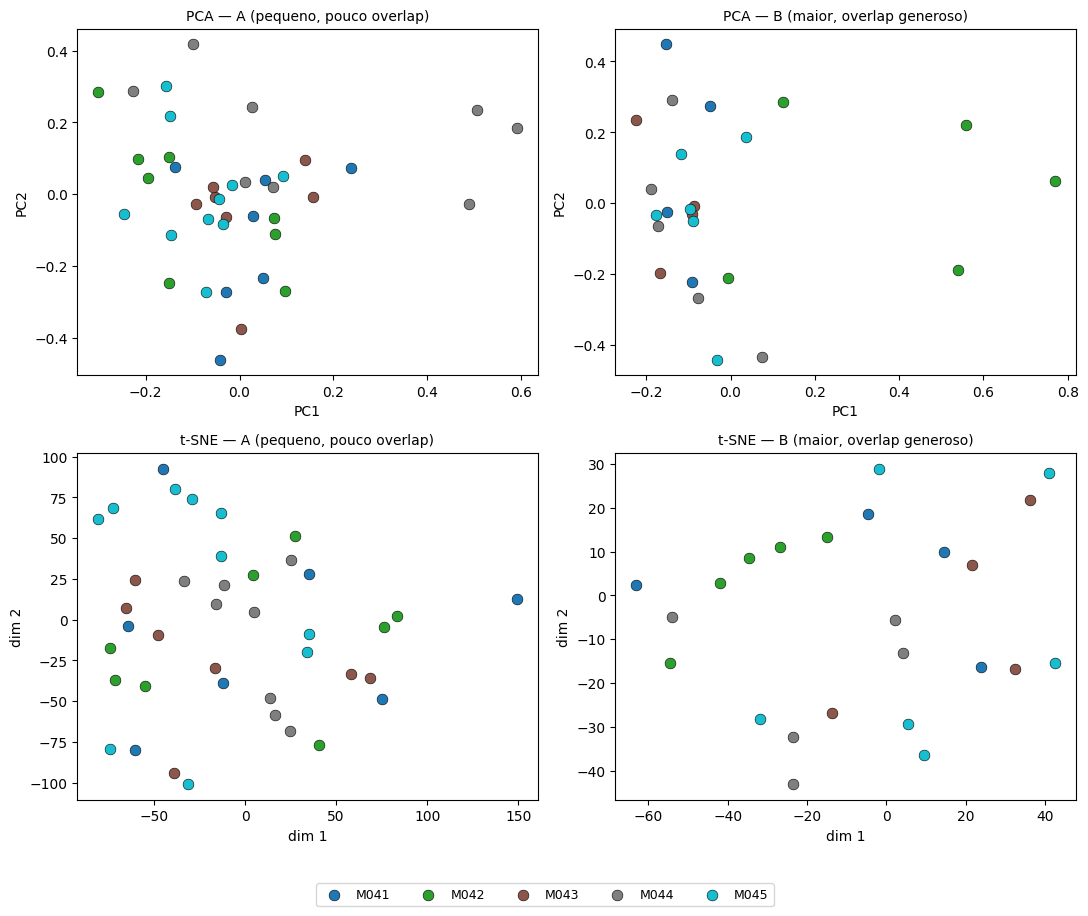

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))

cores = plt.cm.tab10(np.linspace(0, 1, 5))
cor_por_id = dict(zip(IDS_LONGAS_ESPERADAS, cores))

for col, (nome_config, df_chunks) in enumerate(resultados_chunking.items()):
    vetores = np.stack(df_chunks["embedding"].values)

    # PCA
    coords_pca = PCA(n_components=2, random_state=42).fit_transform(vetores)
    ax = axes[0, col]
    for manif_id in IDS_LONGAS_ESPERADAS:
        mask = (df_chunks["manifestacao_id"] == manif_id).values
        ax.scatter(coords_pca[mask, 0], coords_pca[mask, 1], color=cor_por_id[manif_id],
                   label=manif_id, s=60, edgecolor="black", linewidth=0.4)
    ax.set_title(f"PCA — {nome_config}", fontsize=10)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")

    # t-SNE (perplexity baixa por termos poucos pontos)
    n_pontos = vetores.shape[0]
    perplexity = max(2, min(5, n_pontos - 1))
    coords_tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity, init="pca").fit_transform(vetores)
    ax2 = axes[1, col]
    for manif_id in IDS_LONGAS_ESPERADAS:
        mask = (df_chunks["manifestacao_id"] == manif_id).values
        ax2.scatter(coords_tsne[mask, 0], coords_tsne[mask, 1], color=cor_por_id[manif_id],
                    label=manif_id, s=60, edgecolor="black", linewidth=0.4)
    ax2.set_title(f"t-SNE — {nome_config}", fontsize=10)
    ax2.set_xlabel("dim 1"); ax2.set_ylabel("dim 2")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig("chunks_pca_tsne.png", dpi=150, bbox_inches="tight")
plt.show()

### Discussão: os chunks de uma mesma manifestação ficam próximos?

Nos gráficos acima, cada cor representa uma das 5 manifestações longas. Em geral, os pontos de
uma mesma cor tendem a formar pequenos agrupamentos visíveis, tanto no PCA quanto no t-SNE,
confirmando que o chunking preserva boa parte da identidade temática do documento original — o
vocabulário específico de cada denúncia (por exemplo, termos sobre drenagem pluvial em M041
versus termos sobre resíduos industriais em M045) mantém os chunks de uma mesma manifestação
vetorialmente próximos, mesmo com apenas TF-IDF como representação. Essa proximidade tende a ser
um pouco mais compacta na Config B (chunks maiores com mais overlap), já que cada chunk carrega
mais contexto e vocabulário compartilhado com os vizinhos. Vale notar que, com uma representação
de embeddings semânticos reais (como um sentence-transformer multilíngue), a expectativa é que
esse agrupamento fique ainda mais nítido, já que embeddings densos capturam similaridade de
significado além da simples coincidência de palavras usada pelo TF-IDF.

## 6. Conclusão da Entrega 3

- O `RecursiveCharacterTextSplitter` do LangChain, com sua estratégia hierárquica de separadores,
  conseguiu segmentar as 5 manifestações longas em chunks coerentes nas duas configurações testadas.
- Maior `chunk_overlap` (Config B) aumenta a coesão semântica medida entre chunks consecutivos,
  mas parte desse ganho vem de texto literalmente duplicado entre chunks vizinhos, não apenas de
  continuidade de sentido.
- Para o contexto de denúncias de ouvidoria, onde preservar a relação causa/consequência do
  relato é importante, a Config B (`chunk_size=350`, `chunk_overlap=100`) preserva melhor o
  sentido geral de cada denúncia, ao custo de gerar chunks um pouco menos granulares.
- A visualização em 2D (PCA e t-SNE) confirma que os chunks de uma mesma manifestação tendem a
  ficar próximos entre si, mesmo usando TF-IDF como representação vetorial (substituto documentado
  de um sentence-transformer, indisponível neste ambiente sem acesso à internet).